In [2]:
# ============================================================
# ЛАБОРАТОРНАЯ РАБОТА: EDA датасета Fish Market
# Формат вектора признаков: Species, Weight, Length1, Length2,
#                           Length3, Height, Width
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
pd.set_option('display.width', 120)

RANDOM_STATE = 42

In [6]:
# Загрузка датасета Fish.csv (положить файл рядом с ноутбуком)
df = pd.read_csv('Fish.csv')

FEATURES = ['Species','Weight','Length1','Length2','Length3','Height','Width']
df = df[FEATURES].copy()

print("Размер датасета:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (159, 7)

Типы данных:
Species        str
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

Первые 5 строк:


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [7]:
print("Описательные статистики:")
df.describe(include='all').T

print("Численность по видам:")
print(df['Species'].value_counts())

Описательные статистики:
Численность по видам:
Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64


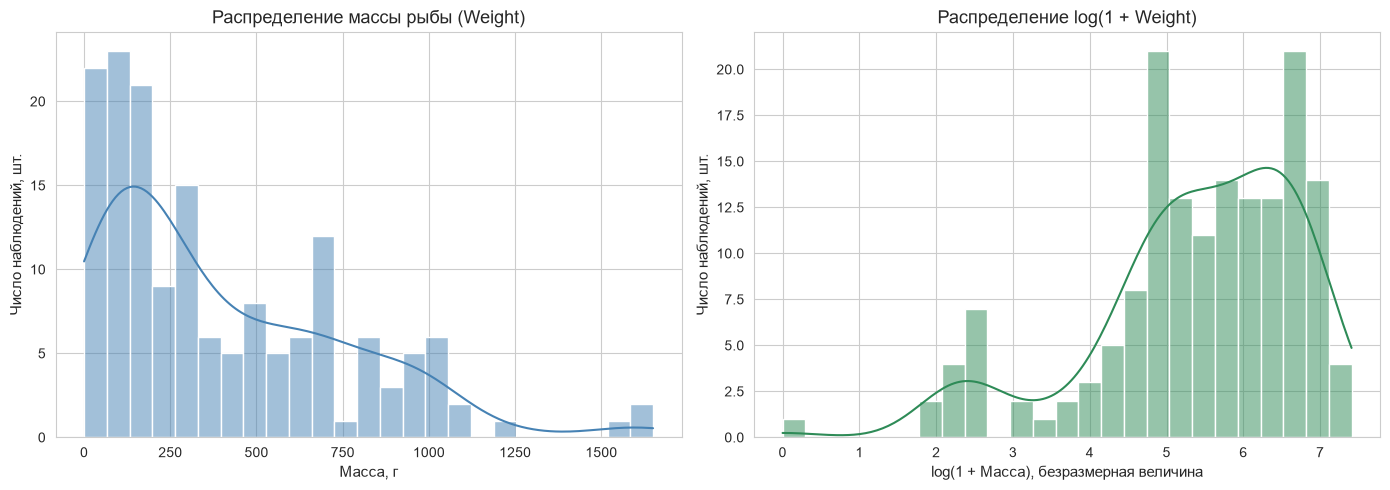

Асимметрия (skew), исходная шкала: 1.104
Асимметрия (skew), лог-шкала:      -1.162
Shapiro-Wilk p-value (исходная):   7.6059e-10
Shapiro-Wilk p-value (лог):        1.1928e-08


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обычная шкала
sns.histplot(df['Weight'], kde=True, bins=25, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение массы рыбы (Weight)')
axes[0].set_xlabel('Масса, г')
axes[0].set_ylabel('Число наблюдений, шт.')

# Логарифмическая шкала
sns.histplot(np.log1p(df['Weight']), kde=True, bins=25, ax=axes[1], color='seagreen')
axes[1].set_title('Распределение log(1 + Weight)')
axes[1].set_xlabel('log(1 + Масса), безразмерная величина')
axes[1].set_ylabel('Число наблюдений, шт.')

plt.tight_layout()
plt.show()

# Числовые характеристики асимметрии и нормальности
skew_raw = df['Weight'].skew()
skew_log = np.log1p(df['Weight']).skew()
shapiro_raw = stats.shapiro(df['Weight']).pvalue
shapiro_log = stats.shapiro(np.log1p(df['Weight'])).pvalue

print(f"Асимметрия (skew), исходная шкала: {skew_raw:.3f}")
print(f"Асимметрия (skew), лог-шкала:      {skew_log:.3f}")
print(f"Shapiro-Wilk p-value (исходная):   {shapiro_raw:.4e}")
print(f"Shapiro-Wilk p-value (лог):        {shapiro_log:.4e}")

C:\Users\Liza\AppData\Local\Temp\ipykernel_25956\4166498697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', ax=axes[0], palette='Set2', order=order)
C:\Users\Liza\AppData\Local\Temp\ipykernel_25956\4166498697.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Species', y='Weight', ax=axes[1],


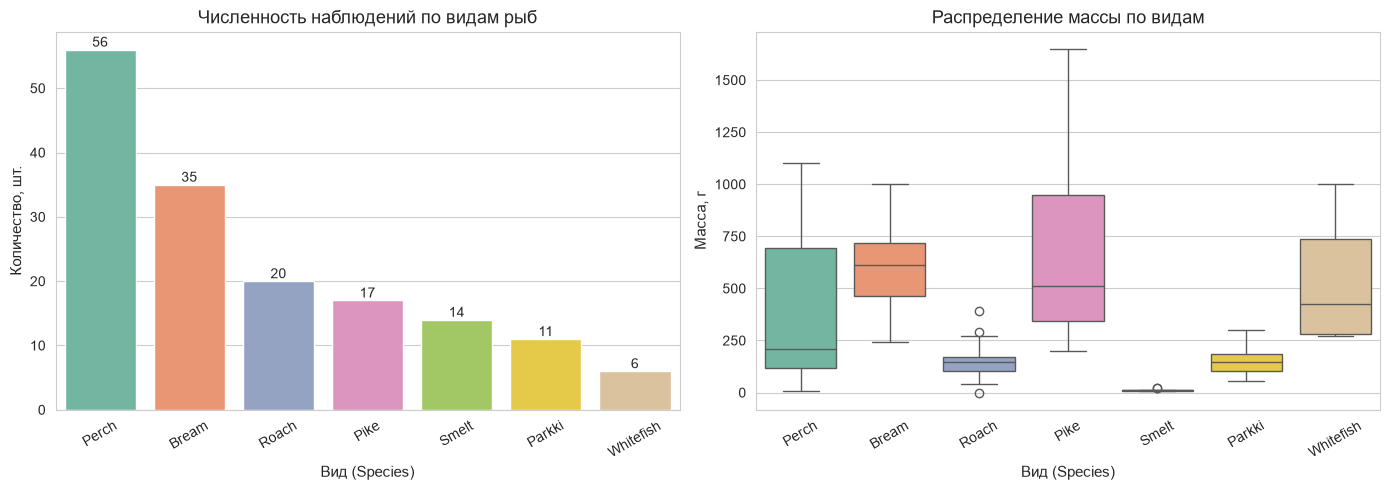

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Численность
order = df['Species'].value_counts().index
sns.countplot(data=df, x='Species', ax=axes[0], palette='Set2', order=order)
axes[0].set_title('Численность наблюдений по видам рыб')
axes[0].set_xlabel('Вид (Species)')
axes[0].set_ylabel('Количество, шт.')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Боксплот массы
sns.boxplot(data=df, x='Species', y='Weight', ax=axes[1],
            palette='Set2', order=order)
axes[1].set_title('Распределение массы по видам')
axes[1].set_xlabel('Вид (Species)')
axes[1].set_ylabel('Масса, г')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

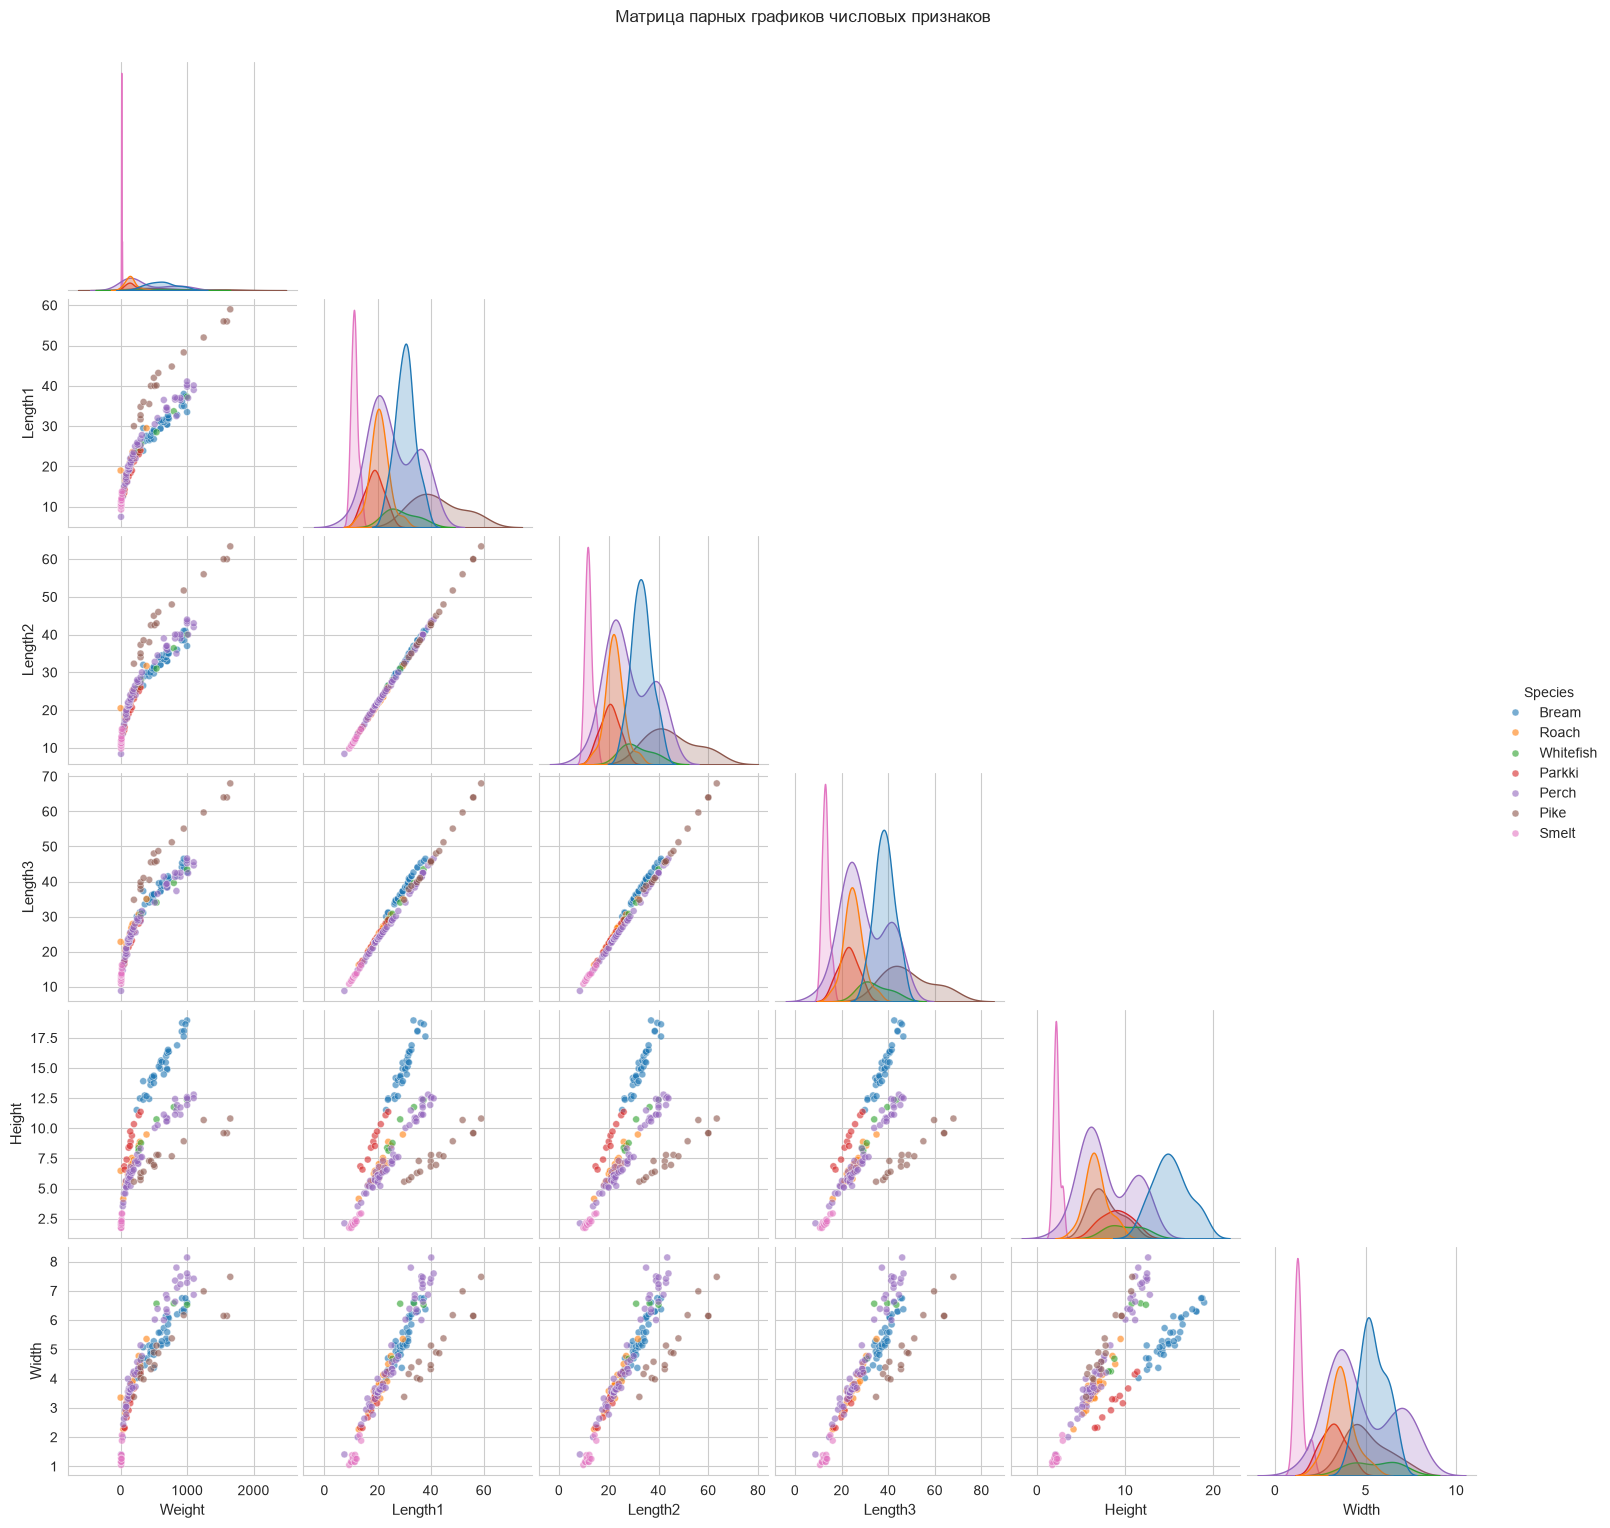

In [10]:
cols = ['Weight','Length1','Length2','Length3','Height','Width']

g = sns.pairplot(df[cols + ['Species']], hue='Species',
                 diag_kind='kde', corner=True,
                 plot_kws={'alpha':0.6, 's':25})
g.fig.suptitle('Матрица парных графиков числовых признаков', y=1.02)
plt.show()

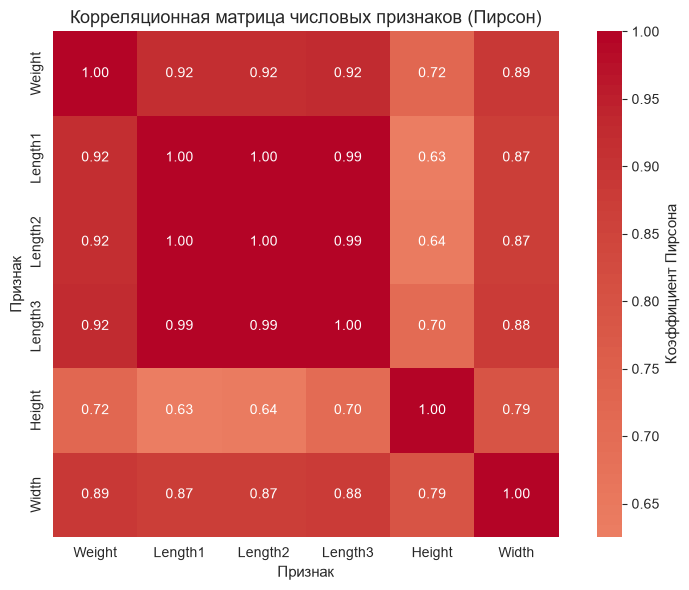

Spearman (Weight vs Length3): 0.964
Pearson  (Weight vs Length3): 0.923


In [11]:
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Коэффициент Пирсона'})
plt.title('Корреляционная матрица числовых признаков (Пирсон)')
plt.xlabel('Признак')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# Spearman для проверки нелинейных монотонных связей
corr_s = df[cols].corr(method='spearman')
print("Spearman (Weight vs Length3):", round(corr_s.loc['Weight','Length3'], 3))
print("Pearson  (Weight vs Length3):", round(corr.loc['Weight','Length3'], 3))

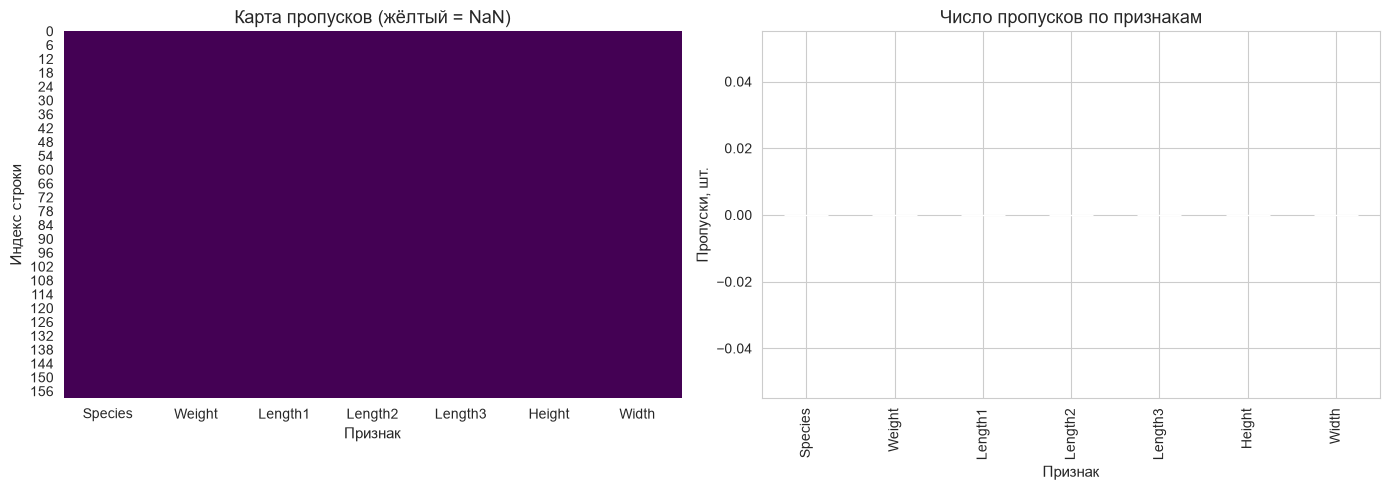

         Пропуски, шт.  Пропуски, %  Уникальных, шт.      Тип
Species              0          0.0                7      str
Weight               0          0.0              101  float64
Length1              0          0.0              116  float64
Length2              0          0.0               93  float64
Length3              0          0.0              124  float64
Height               0          0.0              154  float64
Width                0          0.0              152  float64

Полных дубликатов строк: 0
Отрицательных значений:   0
Нулевых значений:         1


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Карта пропусков
sns.heatmap(df.isna(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Карта пропусков (жёлтый = NaN)')
axes[0].set_xlabel('Признак')
axes[0].set_ylabel('Индекс строки')

# Столбиковая диаграмма пропусков
df.isna().sum().plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Число пропусков по признакам')
axes[1].set_xlabel('Признак')
axes[1].set_ylabel('Пропуски, шт.')

plt.tight_layout()
plt.show()

# Таблица качества данных
quality = pd.DataFrame({
    'Пропуски, шт.': df.isna().sum(),
    'Пропуски, %':  (df.isna().mean()*100).round(2),
    'Уникальных, шт.': df.nunique(),
    'Тип': df.dtypes.astype(str)
})
print(quality)

print("\nПолных дубликатов строк:", df.duplicated().sum())
print("Отрицательных значений:  ", int((df[cols] < 0).sum().sum()))
print("Нулевых значений:        ", int((df[cols] == 0).sum().sum()))

In [13]:
def outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (series < lo) | (series > hi), (lo, hi)

def outliers_mad(series, threshold=3.5):
    med = series.median()
    mad = (series - med).abs().median()
    z = 0.6745 * (series - med) / mad
    return z.abs() > threshold, z

mask_iqr, (lo_w, hi_w) = outliers_iqr(df['Weight'])
mask_mad, z_mad = outliers_mad(df['Weight'])

print(f"IQR-границы Weight: [{lo_w:.1f}, {hi_w:.1f}]")
print(f"Количество выбросов по IQR: {mask_iqr.sum()}")
print(f"Количество выбросов по MAD: {mask_mad.sum()}")

report = pd.DataFrame({
    'index': df.index,
    'Weight': df['Weight'].values,
    'IQR_out': mask_iqr.values,
    'MAD_z': z_mad.round(2).values,
    'MAD_out': mask_mad.values
})
print("\nПодозрительные строки:")
print(report[report['IQR_out'] | report['MAD_out']])

IQR-границы Weight: [-675.0, 1445.0]
Количество выбросов по IQR: 3
Количество выбросов по MAD: 3

Подозрительные строки:
     index  Weight  IQR_out  MAD_z  MAD_out
142    142  1600.0     True   4.39     True
143    143  1550.0     True   4.22     True
144    144  1650.0     True   4.55     True


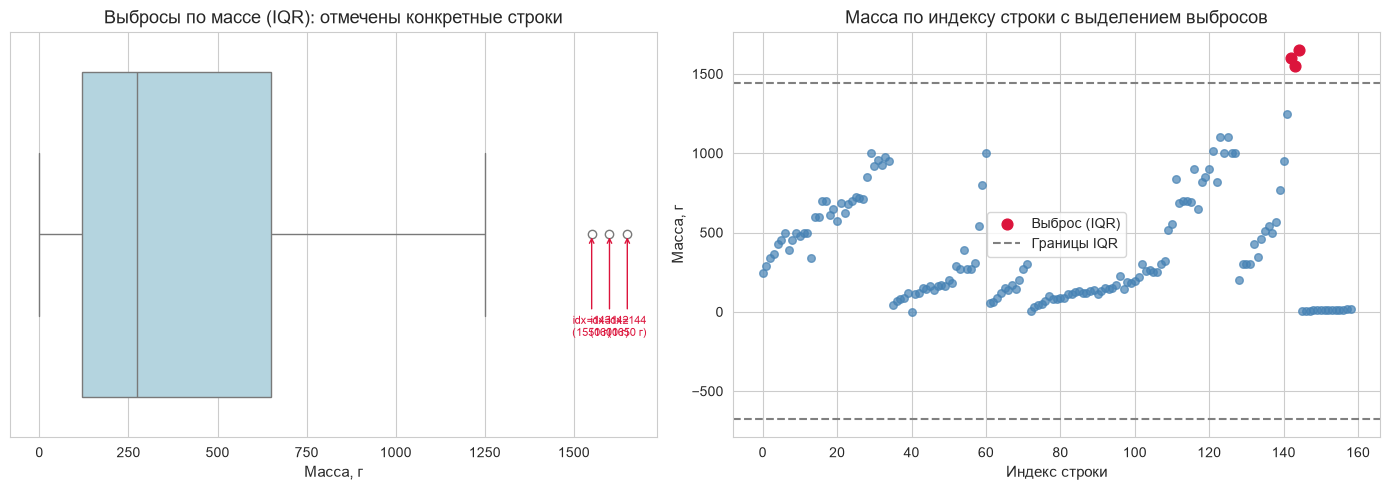

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Боксплот
sns.boxplot(x=df['Weight'], ax=axes[0], color='lightblue')
axes[0].set_title('Выбросы по массе (IQR): отмечены конкретные строки')
axes[0].set_xlabel('Масса, г')
axes[0].set_ylabel('')

for _, row in report[report['IQR_out']].iterrows():
    axes[0].annotate(f"idx={int(row['index'])}\n({row['Weight']:.0f} г)",
                     xy=(row['Weight'], 0),
                     xytext=(row['Weight'], 0.25),
                     ha='center', fontsize=8, color='crimson',
                     arrowprops=dict(arrowstyle='->', color='crimson'))

# Scatter по индексу
axes[1].scatter(df.index, df['Weight'], c='steelblue', alpha=0.7, s=30)
axes[1].scatter(report.loc[mask_iqr.values, 'index'],
                report.loc[mask_iqr.values, 'Weight'],
                c='crimson', s=60, label='Выброс (IQR)')
axes[1].axhline(lo_w, color='gray', ls='--', label=f'Границы IQR')
axes[1].axhline(hi_w, color='gray', ls='--')
axes[1].set_title('Масса по индексу строки с выделением выбросов')
axes[1].set_xlabel('Индекс строки')
axes[1].set_ylabel('Масса, г')
axes[1].legend()

plt.tight_layout()
plt.show()

c:\Users\Liza\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


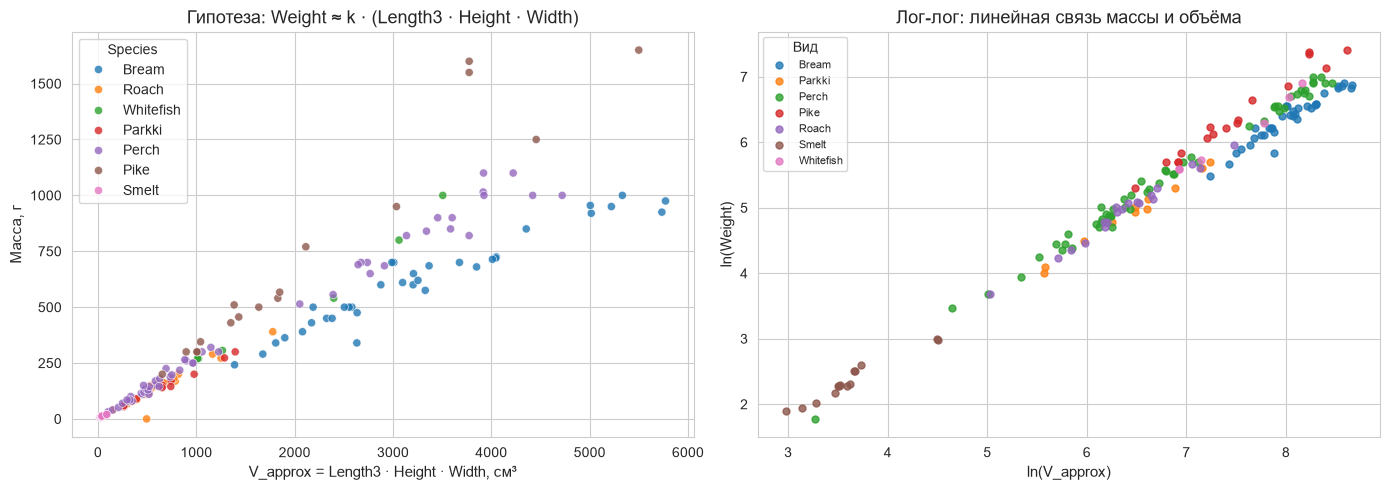

Pearson r (log-log): nan
Spearman r:          0.981


c:\Users\Liza\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2895: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\Liza\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2900: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())


In [15]:
# Физическая гипотеза: масса ∝ объёму тела.
# Новый признак не использует целевую переменную Weight!
df['V_approx'] = df['Length3'] * df['Height'] * df['Width']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Общая зависимость
sns.scatterplot(data=df, x='V_approx', y='Weight', hue='Species',
                ax=axes[0], alpha=0.8, s=35)
axes[0].set_title('Гипотеза: Weight ≈ k · (Length3 · Height · Width)')
axes[0].set_xlabel('V_approx = Length3 · Height · Width, см³')
axes[0].set_ylabel('Масса, г')

# Лог-лог по видам
for sp, g in df.groupby('Species'):
    axes[1].scatter(np.log(g['V_approx']), np.log(g['Weight']),
                    label=sp, alpha=0.8, s=25)
axes[1].set_title('Лог-лог: линейная связь массы и объёма')
axes[1].set_xlabel('ln(V_approx)')
axes[1].set_ylabel('ln(Weight)')
axes[1].legend(fontsize=8, title='Вид')

plt.tight_layout()
plt.show()

r_log = np.corrcoef(np.log(df['V_approx']), np.log(df['Weight']))[0, 1]
r_sp  = stats.spearmanr(df['V_approx'], df['Weight']).correlation
print(f"Pearson r (log-log): {r_log:.3f}")
print(f"Spearman r:          {r_sp:.3f}")

In [16]:
rows = []
for col in ['Weight','Length1','Length2','Length3','Height','Width']:
    s = df[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    med = s.median()
    mad = (s - med).abs().median()
    z = 0.6745 * (s - med) / mad
    rows.append({
        'Признак': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Нижняя граница': round(lo, 2),
        'Верхняя граница': round(hi, 2),
        'Выбросов IQR, шт.': int(((s < lo) | (s > hi)).sum()),
        'MAD': round(mad, 3),
        'Выбросов MAD (|z|>3.5), шт.': int((z.abs() > 3.5).sum()),
    })

outliers_table = pd.DataFrame(rows)
outliers_table

,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,"Выбросов IQR, шт.",MAD,"Выбросов MAD (|z|>3.5), шт."
0,Weight,120.00,650.00,530.00,-675.00,1445.00,3,204.000,3
1,Length1,19.05,32.70,13.65,-1.43,53.18,3,6.600,0
2,Length2,21.00,35.50,14.50,-0.75,57.25,3,7.300,0
3,Length3,23.15,39.65,16.50,-1.60,64.40,1,8.600,0
4,Height,5.94,12.37,6.42,-3.69,22.00,0,2.704,0
5,Width,3.39,5.58,2.20,0.09,8.88,0,1.030,0


In [17]:
# --- Гипотеза 1 (физическая) ---
# V_approx = L3 · H · W  ∝ Weight  — подтверждена в ячейке 10.
# Новый признак рассчитан без Weight → безопасен для модели.

# --- Гипотеза 2 (категориальная) ---
# Species не имеет естественного порядка → One-Hot Encoding.
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(df[['Species']])
print("Категории, известные кодировщику:", list(enc.categories_[0]))
print("Пример вектора:", enc.transform(df[['Species']].head(1)).ravel())

Категории, известные кодировщику: ['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish']
Пример вектора: [1. 0. 0. 0. 0. 0. 0.]


In [18]:
# Стратифицированное разбиение 60/20/20 по видам
train, temp = train_test_split(df, test_size=0.4,
                               stratify=df['Species'],
                               random_state=RANDOM_STATE)
val, test = train_test_split(temp, test_size=0.5,
                             stratify=temp['Species'],
                             random_state=RANDOM_STATE)

print(f"Train: {len(train)} ({len(train)/len(df):.0%})")
print(f"Val:   {len(val)}   ({len(val)/len(df):.0%})")
print(f"Test:  {len(test)}  ({len(test)/len(df):.0%})")
print("\nРаспределение видов в train:")
print(train['Species'].value_counts())

Train: 95 (60%)
Val:   32   (20%)
Test:  32  (20%)

Распределение видов в train:
Species
Perch        33
Bream        21
Roach        12
Pike         10
Smelt         8
Parkki        7
Whitefish     4
Name: count, dtype: int64
